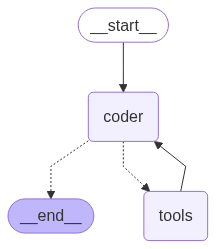

In [7]:
# Trying to build Multi Agents with Supervisor
# Start -> Supervisor -> Coder Agent(python)         -> End
#                     -> Web Search Agent    -> End
# Define function/logic for Coder

from langchain_experimental.utilities.python import PythonREPL
from langchain.tools import tool
from typing import List, Literal, TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import display, Image

def show_app_graph(app):
    display(Image(app.get_graph().draw_mermaid_png()))


@tool
def python_repl_tool(code):
    """
    This is a coder function to execute a python code using langchain_experimental python REPL.
    It's still in experimental stage however this serves the purpose.
    """
    repl = PythonREPL()
    try:
        result = repl.run(code)
    except BaseException as ex:
        return f"Failed to execute code:{repr(ex)}"
    return f"Successfully Executed code. \n\`\`\`{code}\`\`\` \nResult:{result}"

# Define Coder State for Coder Node
class CoderState(TypedDict):
    messages: Annotated[list,add_messages]

    

# Define llm for coder agent
llm_coder =    ChatOpenAI(model="gpt-4o-mini")
llm_coder_bind_tools = llm_coder.bind_tools([python_repl_tool])

# Node function for state graph
def coder(state: CoderState) -> CoderState:
    result = llm_coder_bind_tools.invoke(state["messages"])
    return {"messages":result}
    
# Define coder state graph for coder agent
coder_graph = StateGraph(CoderState)

tools = [python_repl_tool]

# Define nodes for Function/Logic
coder_graph.add_node("coder",coder)
coder_graph.add_node("tools",ToolNode(tools))

# Define Edges/Connections/Links
coder_graph.add_edge(START, "coder")
coder_graph.add_conditional_edges("coder", tools_condition)
coder_graph.add_edge("tools","coder")

coder_app = coder_graph.compile()

show_app_graph(coder_app)    


In [9]:
result = coder_app.invoke({"messages":[HumanMessage("""# A lambda function to double a number
double = lambda x: x * 2

print(double(5)) # Output: 10

# Using a lambda with map()
numbers = [1, 2, 3, 4]
doubled_numbers = list(map(lambda x: x * 2, numbers))
print(doubled_numbers) # Output: [2, 4, 6, 8]""")]})

Python REPL can execute arbitrary code. Use with caution.


In [12]:
result

{'messages': [HumanMessage(content='# A lambda function to double a number\ndouble = lambda x: x * 2\n\nprint(double(5)) # Output: 10\n\n# Using a lambda with map()\nnumbers = [1, 2, 3, 4]\ndoubled_numbers = list(map(lambda x: x * 2, numbers))\nprint(doubled_numbers) # Output: [2, 4, 6, 8]', additional_kwargs={}, response_metadata={}, id='ad819640-97be-4af2-8b1c-0abd1830e1ab'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_86CKpAzITvZZut6cHRnfpZyI', 'function': {'arguments': '{"code":"# A lambda function to double a number\\ndouble = lambda x: x * 2\\n\\nprint(double(5)) # Output: 10\\n\\n# Using a lambda with map()\\nnumbers = [1, 2, 3, 4]\\ndoubled_numbers = list(map(lambda x: x * 2, numbers))\\nprint(doubled_numbers) # Output: [2, 4, 6, 8]"}', 'name': 'python_repl_tool'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 110, 'prompt_tokens': 158, 'total_tokens': 268, 'completion_tokens_details': {'accepted_predi

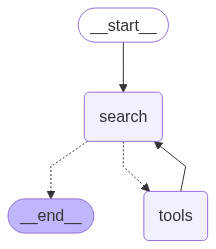

In [8]:
# Trying to build Multi Agents with Supervisor
# Start -> Supervisor -> Coder Agent(python)         -> End
#                     -> Web Search Agent    -> End
# Define function/logic for Coder

from langchain_experimental.utilities.python import PythonREPL
from langchain.tools import tool, DuckDuckGoSearchRun
from typing import List, Literal, TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition



# This is a Search tool from langchain, no external specification of decorators tool not required
web_search = DuckDuckGoSearchRun()

# Define Web search State for Search Node
class WebsearchState(TypedDict):
    messages: Annotated[list,add_messages]

    

# Define llm for Search agent
llm_search =    ChatOpenAI(model="gpt-4o-mini")
llm_search_bind_tools = llm_search.bind_tools([web_search])

# Node function for state graph
def search_web(state: WebsearchState) -> WebsearchState:
    result = llm_search_bind_tools.invoke(state["messages"])
    return {"messages":result}
    
# Define Search state graph for Search agent
search_graph = StateGraph(WebsearchState)

tools = [web_search]

# Define nodes for Function/Logic
search_graph.add_node("search",search_web)
search_graph.add_node("tools",ToolNode(tools))

# Define Edges/Connections/Links
search_graph.add_edge(START, "search")
search_graph.add_conditional_edges("search", tools_condition)
search_graph.add_edge("tools","search")

search_app = search_graph.compile()

show_app_graph(search_app)   

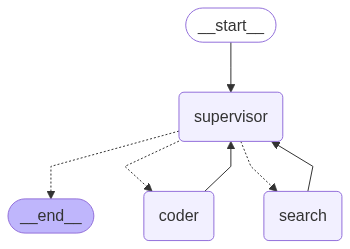

In [11]:
from langchain_experimental.utilities.python import PythonREPL
from langchain.tools import tool, DuckDuckGoSearchRun
from typing import List, Literal, TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage,SystemMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from pydantic import BaseModel, Field


# Define structured route model
# It's just a router class helps you to return what to return

class Route(BaseModel):
    """
    when a worker node is needed, route to next worker node. If no workers needed route to FINISH
    """
    next_node: Literal["coder","search","FINISH"] = Field(description="when a worker node is needed, route to next worker node. If no workers needed route to FINISH")

# Define llm for supervisor agent
# when this model invoked decide what agent to call
llm_supervisor =    ChatOpenAI(model="gpt-4o-mini").with_structured_output(Route)

agents = ["search","coder"]

supervisor_prompt = SystemMessage(f"""You are a supervisor tasked with managing a conversation between the following workers: {agents}.
Given the following user request, respond with the worker to act next.
Each worker will perform a task and respond with their results and status.
When finished, respond with FINISH.
""")

class State(TypedDict):
    messages: Annotated[list, add_messages]
    next_node: str

def supervisor(state: State):
    result = llm_supervisor.invoke([supervisor_prompt] + state["messages"])
    return {"messages": AIMessage(result.next_node),"next_node":result.next_node}


# we need conditional edge function to return agent name from supervisior
# supervisor will return state but we need to return agent 

def node_selector(state: State) -> Literal["coder","search","__end__"]:
    if state["next_node"] == "FINISH":
        result = "__end__"
    else:
        result = state["next_node"]
    return result
    
builder = StateGraph(State)

builder.add_node("supervisor",supervisor)
builder.add_node("search",search_app)
builder.add_node("coder",coder_app)

builder.add_edge(START,"supervisor")
builder.add_conditional_edges("supervisor",node_selector)
builder.add_edge("search","supervisor")
builder.add_edge("coder","supervisor")

app = builder.compile()

show_app_graph(app)



In [12]:
question_1 = """# A lambda function to double a number
double = lambda x: x * 2

print(double(5)) # Output: 10

# Using a lambda with map()
numbers = [1, 2, 3, 4]
doubled_numbers = list(map(lambda x: x * 2, numbers))
print(doubled_numbers) # Output: [2, 4, 6, 8]"""
question_2 = "who is the president of india as on today, 20th August 2025?"

result_1 = app.invoke({"messages":[HumanMessage(question_1)]})
result_2 = app.invoke({"messages":[HumanMessage(question_2)]})


C:\Users\Asus\PycharmProjects\GenAIPractise\.venv\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
C:\Users\Asus\PycharmProjects\GenAIPractise\.venv\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


In [15]:
question_3 ="How the GDP of uttar pradesh has grown in the last 3 years from 2023. Show me a bar chart for the same."
result_3 = app.invoke({"messages":[HumanMessage(question_3)]})
result_3

C:\Users\Asus\PycharmProjects\GenAIPractise\.venv\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
C:\Users\Asus\PycharmProjects\GenAIPractise\.venv\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
C:\Users\Asus\PycharmProjects\GenAIPractise\.venv\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
C:\Users\Asus\PycharmProjects\GenAIPractise\.venv\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` inst

{'messages': [HumanMessage(content='How the GDP of uttar pradesh has grown in the last 3 years from 2023. Show me a bar chart for the same.', additional_kwargs={}, response_metadata={}, id='92ea21bd-dbef-48fe-9aa8-0c7aebf0765c'),
  AIMessage(content='search', additional_kwargs={}, response_metadata={}, id='8381bbc9-2838-4274-9c0f-41ea32233621'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_ArumvNRZJxCB3xFOPpqGpk8D', 'function': {'arguments': '{"query":"Uttar Pradesh GDP growth last 3 years 2023"}', 'name': 'duckduckgo_search'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 108, 'total_tokens': 136, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_560af6e559', 'id': 'chatc